In [ ]:
from google.colab import files
uploaded = files.upload()


Saving HR_Data_Analysis_DataSource_Video.xlsx to HR_Data_Analysis_DataSource_Video.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("HR_Data_Analysis_DataSource_Video.xlsx")
df.head()

,EmployeeID,FirstName,LastName,Gender,DateOfBirth,Nationality,MaritalStatus,EducationLevel,Email,DateOfJoining,DateOfLeaving,ReasonForLeaving,VoluntaryExit,RecruitmentSource,TimeToHire,CostPerHire
0,110001,Gwyn,Etzel,F,1980-05-17,UK,Single,Associate’s Degree,gwyn.etzel@lumen.com,2024-06-19,NaT,NaN,NaN,3,45,3000
1,110002,Ressie,Goodwyn,F,1969-04-29,UK,Single,Master’s Degree,ressie.goodwyn@lumen.com,2024-03-29,NaT,NaN,NaN,2,48,2000
2,110003,Colton,Salzman,M,1997-09-27,USA,Single,Technical Certificate,colton.salzman@lumen.com,2024-03-03,NaT,NaN,NaN,2,57,4000
3,110004,Marylynn,Ealey,F,1991-08-01,Australia,Single,Technical Certificate,marylynn.ealey@lumen.com,2024-03-11,NaT,NaN,NaN,4,50,2500
4,110005,Bula,Reich,F,1991-04-16,Australia,Single,Master’s Degree,bula.reich@lumen.com,2024-02-08,NaT,NaN,NaN,4,34,3200


In [ ]:
df_main = pd.read_excel(file_path, sheet_name='DimEmployee1')

In [ ]:
df_exit = pd.read_excel(file_path, sheet_name='FactEmployeeDetails (2)')

In [ ]:
df_final = pd.merge(df_main, df_exit, on='EmployeeID', how='left')

In [ ]:
df_final.head()

,EmployeeID,FirstName,LastName,Gender,DateOfBirth,Nationality,MaritalStatus,EducationLevel,Email,DateOfJoining,...,EngagementScore,SatisfactionScore,ReasonForLeaving_y,VoluntaryExit_y,TrainingHours,MandatoryTrainingsAssigned,MandatoryTrainingsCompleted,RecruitmentSource_y,TimeToHire_y,CostPerHire_y
0,110001,Gwyn,Etzel,F,1980-05-17,UK,Single,Associate’s Degree,gwyn.etzel@lumen.com,2024-06-19,...,93,97,"""null""","""null""",35,7,6,3,45,3000
1,110002,Ressie,Goodwyn,F,1969-04-29,UK,Single,Master’s Degree,ressie.goodwyn@lumen.com,2024-03-29,...,100,91,"""null""","""null""",10,7,7,2,48,2000
2,110003,Colton,Salzman,M,1997-09-27,USA,Single,Technical Certificate,colton.salzman@lumen.com,2024-03-03,...,99,93,"""null""","""null""",54,9,9,2,57,4000
3,110004,Marylynn,Ealey,F,1991-08-01,Australia,Single,Technical Certificate,marylynn.ealey@lumen.com,2024-03-11,...,93,90,"""null""","""null""",64,10,9,4,50,2500
4,110005,Bula,Reich,F,1991-04-16,Australia,Single,Master’s Degree,bula.reich@lumen.com,2024-02-08,...,97,91,"""null""","""null""",32,9,9,4,34,3200


In [ ]:
df_final['DateOfJoining'] = pd.to_datetime(df_final['DateOfJoining'])


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

today = pd.to_datetime(datetime.now())

def calculate_tenure(row):
    start = row['DateOfJoining']
    end = row['TerminationDate (New)']

    if pd.isnull(start):
        return np.nan

    # If termination date is null, use today's date for tenure calculation
    if pd.isnull(end):
        duration = today - start
    else:
        duration = end - start

    # Calculate tenure in months (average days in a month is approx 30.44)
    tenure_months = duration.days / 30.44
    return round(tenure_months, 2)

In [ ]:
df_final['DateOfJoining'] = pd.to_datetime(df_final['DateOfJoining'], errors='coerce')
df_final['TerminationDate (New)'] = pd.to_datetime(df_final['TerminationDate (New)'], errors='coerce')

In [ ]:
df_final['Tenure'] = df_final.apply(calculate_tenure, axis=1)

In [ ]:
df_final[['EmployeeID', 'DateOfJoining', 'TerminationDate (New)', 'Tenure']].head()

,EmployeeID,DateOfJoining,TerminationDate (New),Tenure
0,110001,2024-06-19,NaT,22.01
1,110002,2024-03-29,NaT,24.70
2,110003,2024-03-03,NaT,25.56
3,110004,2024-03-11,NaT,25.30
4,110005,2024-02-08,NaT,26.35


In [ ]:
missing_tenure_values = df_final['Tenure'].isnull().sum()
print(f"Number of missing values in 'Tenure' column: {missing_tenure_values}")

Number of missing values in 'Tenure' column: 0


In [ ]:
df_final['Tenure_Months'] = df_final.apply(calculate_tenure, axis=1)

In [ ]:
display(df_final[['EmployeeID', 'DateOfJoining', 'TerminationDate (New)', 'Tenure_Months']].head())

,EmployeeID,DateOfJoining,TerminationDate (New),Tenure_Months
0,110001,2024-06-19,NaT,22.01
1,110002,2024-03-29,NaT,24.70
2,110003,2024-03-03,NaT,25.56
3,110004,2024-03-11,NaT,25.30
4,110005,2024-02-08,NaT,26.35


In [ ]:
df_final['Is_Terminated'] = df_final['TerminationDate (New)'].notnull().astype(int)

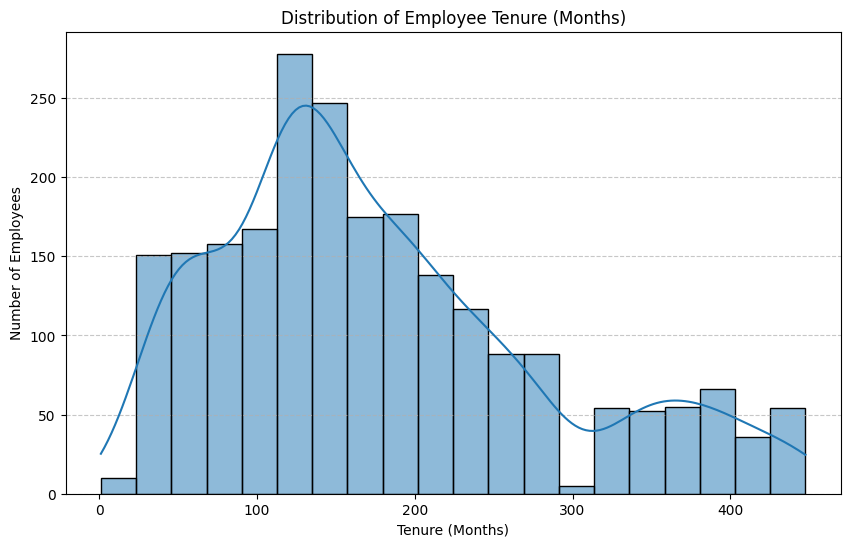

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_final['Tenure_Months'], bins=20, kde=True)
plt.title('Distribution of Employee Tenure (Months)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Employees')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

عدد الموظقين االي لسة موجودين

In [ ]:
print(df_final['TerminationDate (New)'].isna().sum())

2198


In [ ]:
df_left = df_final[df_final['TerminationDate (New)'].notnull()].copy()

In [ ]:
total_left = len(df_left)
print(f"إجمالي عدد الموظفين الذين تركوا الشركة: {total_left}")

إجمالي عدد الموظفين الذين تركوا الشركة: 70
